In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

vOTUs with host associations by linkage method

In [2]:
df_v = pd.read_excel('../data/Supplementary_Data_1_vOTU_metadata.xlsx', usecols=['votu_id','VFC'])

v_pr = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='prophage', usecols=['votu_id']).drop_duplicates().votu_id.tolist()
v_sp = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='spacer matching', usecols=['votu_id']).drop_duplicates().votu_id.tolist()
v_hc = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='Hi-C', usecols=['votu_id']).drop_duplicates().votu_id.tolist()

VFCs with host associations by linkage method

In [3]:
df_vc = pd.read_excel('../data/Supplementary_Data_3_VFC_metadata.xlsx', usecols=['VFC','VC_size'])
df_vc = df_vc[df_vc.VC_size > 1] # non-singleton VFCs
vfcs = df_vc.VFC.tolist()
df_v_in_vfc = df_v[df_v.VFC.isin(vfcs)]

vc_pr = df_v_in_vfc[df_v_in_vfc.votu_id.isin(v_pr)].VFC.unique().tolist()
vc_sp = df_v_in_vfc[df_v_in_vfc.votu_id.isin(v_sp)].VFC.unique().tolist()
vc_hc = df_v_in_vfc[df_v_in_vfc.votu_id.isin(v_hc)].VFC.unique().tolist()

"host associations being mapped for a majority of vOTUs (**>55%**) and nearly all VFCs (**>96%**)"

In [4]:
print(f'% of vOTUs with host associations = {len(set(v_pr) | set(v_sp) | set(v_hc))/len(df_v)*100:.1f}%, % of VFCs with host associations = {len(set(vc_pr) | set(vc_sp) | set(vc_hc))/len(vfcs)*100:.1f}%')

% of vOTUs with host associations = 55.7%, % of VFCs with host associations = 96.6%


"Hi-C data provided host information for the largest number of vOTUs (**>12,000** versus **<8,000** for spacer matching and prophage analysis), with **>6,000 vOTUs for which only Hi-C data identified host linkages**"

In [5]:
print(f'Number of vOTUs with host associations by: spacer matching = {len(v_sp)}, prophage = {len(v_pr)}, Hi-C = {len(v_hc)}, Hi-C only = {len(set(v_hc) - set(v_sp) - set(v_pr))}')

Number of vOTUs with host associations by: spacer matching = 7891, prophage = 4325, Hi-C = 12514, Hi-C only = 6654


### Supplementary Fig. 15A: Venn diagram of host linkage methods by vOTU

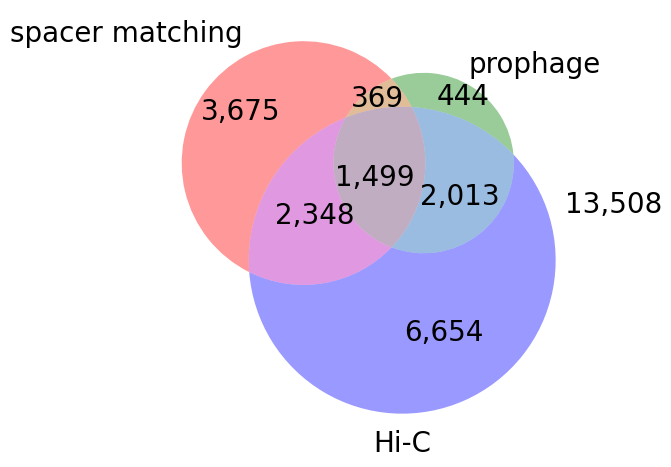

In [6]:
v3 = venn3([set(v_sp), set(v_pr), set(v_hc)], set_labels = ('spacer matching', 'prophage', 'Hi-C'))

fs=20
for text in v3.set_labels:
    text.set_fontsize(fs)

for text in v3.subset_labels:
    text.set_fontsize(fs)
    text.set_text(f"{int(text.get_text()):,}")

l_noh = len(df_v) - len(set(v_pr) | set(v_sp) | set(v_hc))

plt.text(0.6,0,f'{l_noh:,}', fontsize=fs)
plt.tight_layout()
plt.show()

### Supplementary Fig. 15B: Venn diagram of host linkage methods by VFC

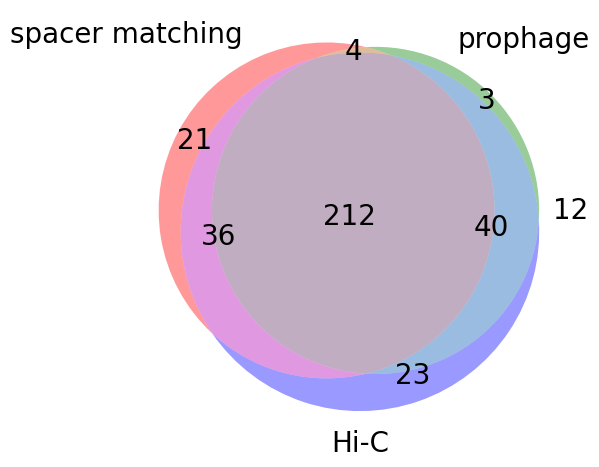

In [7]:
v3 = venn3([set(vc_sp), set(vc_pr), set(vc_hc)], set_labels = ('spacer matching', 'prophage', 'Hi-C'))

fs=20
for text in v3.set_labels:
    text.set_fontsize(fs)

for text in v3.subset_labels:
    text.set_fontsize(fs)
    text.set_text(f"{int(text.get_text()):,}")

l_noh = len(df_vc) - len(set(vc_pr) | set(vc_sp) | set(vc_hc))

plt.text(0.6,0,f'{l_noh:,}', fontsize=fs)
plt.tight_layout()
plt.show()